In [1]:
# ── Import ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ── Preprocessing ───────────────────────────────────────────────
df = pd.read_excel('kuesionardivisipramuka smaba.xlsx')
df.columns = df.columns.str.strip()

for col in ['Nama Lengkap', 'Kelas']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

TARGET = 'Divisi yang paling di minati?'
df = df.fillna(df.mode().iloc[0])

encoders = {}
df_encoded = df.copy()
for col in df.columns:
    is_text = df[col].dtype == 'object' or str(df[col].dtype) == 'string'
    if not is_text:
        is_text = df[col].apply(lambda x: isinstance(x, str)).any()
    if is_text:
        df_encoded[col] = df_encoded[col].astype(str).str.strip()
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        encoders[col] = le

feature_cols = [col for col in df_encoded.columns if col != TARGET]
X = df_encoded[feature_cols].values
y = df_encoded[TARGET].values
label_names = list(encoders[TARGET].classes_)

sm = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = sm.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)
print("Preprocessing selesai!")

Preprocessing selesai!


In [3]:
# ── Model ───────────────────────────────────────────────────────
model = KNeighborsClassifier(n_neighbors=7, weights='distance')
model.fit(X_train, y_train)
print("Training selesai!")

Training selesai!


In [4]:
# ── Evaluasi ────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_res, y_res, cv=cv, scoring='accuracy')

print(f"Train Accuracy : {accuracy_score(y_train, model.predict(X_train)):.4f}")
print(f"Test  Accuracy : {accuracy_score(y_test,  model.predict(X_test)):.4f}")
print(f"CV Mean        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test), target_names=label_names, zero_division=0))

Train Accuracy : 1.0000
Test  Accuracy : 0.7955
CV Mean        : 0.8182 ± 0.0321

Classification Report:
                          precision    recall  f1-score   support

Bimbingan & Pengembangan       0.90      0.82      0.86        11
          Kajian Pramuka       0.75      0.82      0.78        11
                Kegiatan       0.89      0.73      0.80        11
   Penelitian & Evaluasi       0.69      0.82      0.75        11

                accuracy                           0.80        44
               macro avg       0.81      0.80      0.80        44
            weighted avg       0.81      0.80      0.80        44



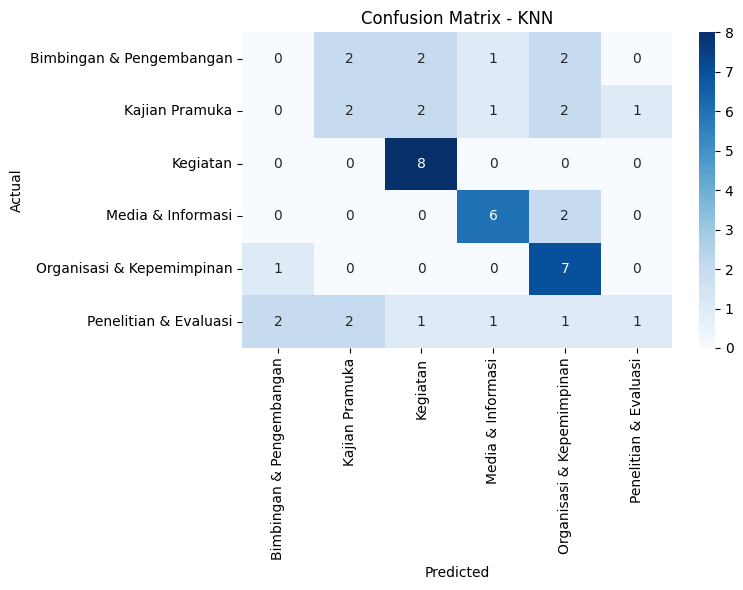

In [5]:
# ── Confusion Matrix ────────────────────────────────────────────
cm = confusion_matrix(y_test, model.predict(X_test))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - KNN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

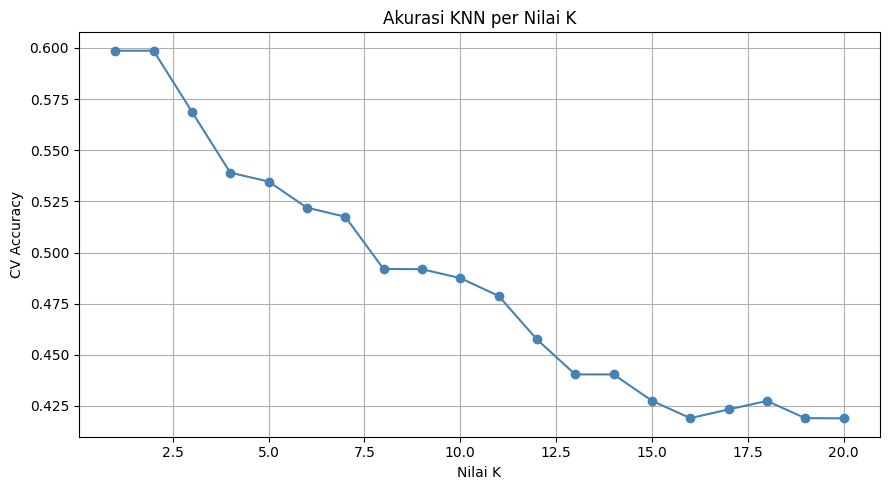

In [6]:
# ── Grafik Akurasi per Nilai K ──────────────────────────────────
k_range = range(1, 21)
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    scores = cross_val_score(knn, X_res, y_res, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

plt.figure(figsize=(9, 5))
plt.plot(k_range, k_scores, marker='o', color='steelblue')
plt.xlabel('Nilai K')
plt.ylabel('CV Accuracy')
plt.title('Akurasi KNN per Nilai K')
plt.grid(True)
plt.tight_layout()
plt.show()